In [1]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import optuna
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor
from Preprocess import preprocess_data_window
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)


c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
data_orig     = pd.read_csv("../Whillians-GPS-Data-and-Features.csv")
filtered_time = pd.read_csv("../filtered_time_to_next_event.csv")


In [3]:
# ── Cell 3: Preprocessing ────────────────────────────────────────────────────
n_previous_events = 20
n_qubits_base = 6

X_train, X_val, X_test, y_train, y_val, y_test, feature_cols = preprocess_data_window(
    filtered_time, data_orig, n_previous_events
)


print("NaN count per column:\n", X_train.isna().sum())
print("Total NaN:", X_train.isna().sum().sum())


X shape:  (2822, 126)
y shape:  (2822,)
NaN count per column:
 tide_deriv-0      0
form_fac-0        0
time_since-0      0
slip_size-0       0
high_t_evt-0      0
                 ..
form_fac-20       0
time_since-20     0
slip_size-20      0
high_t_evt-20     0
tide_height-20    0
Length: 126, dtype: int64
Total NaN: 0


In [4]:
# ── Cell 4: Config ───────────────────────────────────────────────────────────
QRC_CONFIG = {
    "num_layers_per_event": 2, 
    "shots":4096,
    "n_iterations": 5,
    "top_k": 3,
    "correlation_threshold": 0.0,
    "random_seed": 42,
}

CLASSICAL_MODEL_NAME = "Ridge"
n_previous_events = 20

print("QRC Config:", QRC_CONFIG)
print("Classical model:", CLASSICAL_MODEL_NAME)


QRC Config: {'num_layers_per_event': 2, 'shots': 4096, 'n_iterations': 5, 'top_k': 3, 'correlation_threshold': 0.0, 'random_seed': 42}
Classical model: Ridge


In [5]:
# ── Cell 5: Scaling ─────────────────────────────────────────────────────────
def scale_to_pi_range(X_train, X_val, X_test):
    train_min = X_train.min(axis=0)
    train_max = X_train.max(axis=0)
    denom = train_max - train_min
    denom[denom == 0] = 1.0

    def transform(X):
        scaled = (X - train_min) / denom
        scaled = np.clip(scaled, 0.0, 1.0)
        return scaled * np.pi

    return transform(X_train), transform(X_val), transform(X_test)


X_train_sel = X_train.to_numpy()
X_val_sel   = X_val.to_numpy()
X_test_sel  = X_test.to_numpy()

X_train_q, X_val_q, X_test_q = scale_to_pi_range(X_train_sel, X_val_sel, X_test_sel)

# Convert targets to numpy once here for use throughout
y_train_np = y_train.to_numpy() if hasattr(y_train, "to_numpy") else np.array(y_train)
y_val_np   = y_val.to_numpy()   if hasattr(y_val,   "to_numpy") else np.array(y_val)
y_test_np  = y_test.to_numpy()  if hasattr(y_test,  "to_numpy") else np.array(y_test)

n_qubits       = n_qubits_base
n_states       = 2 ** n_qubits


print(f"Input to quantum circuit: {X_train_q.shape}")
print(f"n_qubits: {n_qubits}, n_states: {n_states}")



Input to quantum circuit: (1692, 126)
n_qubits: 6, n_states: 64


In [6]:
# ── Cell 6: Unsupervised regime labelling (K-Means on y_train) + classifier ───

import numpy as np
import optuna
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, classification_report,
                             silhouette_score)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Step 1: K-Means fit  ───────────────────────────────────
km_y = KMeans(n_clusters=2, n_init=50, random_state=42)
km_y.fit(y_train_np.reshape(-1, 1))

order   = np.argsort(km_y.cluster_centers_.ravel())
remap   = {old: new for new, old in enumerate(order)}
centers = km_y.cluster_centers_.ravel()[order]

def _km_label(y_arr):
    """Assign regime labels via trained K-Means.
    ONLY call with y_train_np — calling with val/test y leaks future targets."""
    raw = km_y.predict(y_arr.reshape(-1, 1))
    return np.array([remap[r] for r in raw])

# Train labels only 
y_clf_train = _km_label(y_train_np)

boundary = centers.mean()
print(f"K-Means cluster centres — Short: {centers[0]:.0f} s, Long: {centers[1]:.0f} s")
print(f"Decision boundary (midpoint): {boundary:.0f} s")

sil_train = silhouette_score(y_train_np.reshape(-1, 1), y_clf_train)
print(f"Silhouette score — Train: {sil_train:.4f}")
print(f"Class distribution (train) — Short: {(y_clf_train==0).sum()}, Long: {(y_clf_train==1).sum()}")

# ── Step 2: Train XGBoost classifier on raw X_train features → y_clf_train ───
# Raw features preserve separability that [0, π] scaling compresses.
# The QRC and regressors downstream still use X_train_q 
X_train_raw = X_train.to_numpy()
X_val_raw   = X_val.to_numpy()
X_test_raw  = X_test.to_numpy()

sample_weights_clf = compute_sample_weight("balanced", y_clf_train)

def clf_objective(trial):
    clf = XGBClassifier(
        objective="binary:logistic",
        n_estimators=500,
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 6),
        subsample=trial.suggest_float("subsample", 0.6, 0.9),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 0.9),
        scale_pos_weight=trial.suggest_float("scale_pos_weight", 0.5, 3.0),
        random_state=42,
    )
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    fold_accs = []
    for train_idx, val_idx in skf.split(X_train_raw, y_clf_train):
        X_f, X_v = X_train_raw[train_idx], X_train_raw[val_idx]
        y_f, y_v = y_clf_train[train_idx], y_clf_train[val_idx]
        w_f      = sample_weights_clf[train_idx]
        clf.fit(X_f, y_f, sample_weight=w_f, verbose=False)
        fold_accs.append(accuracy_score(y_v, clf.predict(X_v)))
    return 1.0 - np.mean(fold_accs)

clf_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
clf_study.optimize(clf_objective, n_trials=30)

slip_classifier = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    **clf_study.best_params,
    random_state=42,
    eval_metric="logloss",
)
slip_classifier.fit(
    X_train_raw, y_clf_train,
    sample_weight=sample_weights_clf,
    verbose=False,
)

# ── Step 3: All routing masks from classifier predictions on X ────
clf_train_labels = slip_classifier.predict(X_train_raw)
clf_val_labels   = slip_classifier.predict(X_val_raw)
clf_test_labels  = slip_classifier.predict(X_test_raw)

short_mask_train = clf_train_labels == 0
long_mask_train  = clf_train_labels == 1
short_mask_val   = clf_val_labels   == 0
long_mask_val    = clf_val_labels   == 1

short_test_idx = np.where(clf_test_labels == 0)[0]
long_test_idx  = np.where(clf_test_labels == 1)[0]
short_val_idx  = np.where(clf_val_labels  == 0)[0]
long_val_idx   = np.where(clf_val_labels  == 1)[0]

print(f"\nPredicted class distribution — Train: Short {short_mask_train.sum()}, Long {long_mask_train.sum()}")
print(f"Test routing  — Short: {len(short_test_idx)}, Long: {len(long_test_idx)}")
print(f"Val routing   — Short: {len(short_val_idx)},  Long: {len(long_val_idx)}")



c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\Users\kaitl\anaconda3\envs\icequake-qrc\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


K-Means cluster centres — Short: 45889 s, Long: 83860 s
Decision boundary (midpoint): 64875 s
Silhouette score — Train: 0.7208
Class distribution (train) — Short: 1054, Long: 638

Predicted class distribution — Train: Short 1031, Long 661
Test routing  — Short: 330, Long: 235
Val routing   — Short: 334,  Long: 231


In [7]:
# ── Cell 7: FC-TFI Hamiltonian ────────────────────────────────────────────────


def generate_ising_params(n_qubits, rng, J_std=0.5, h=0.1, t=0.5):
    J = np.zeros((n_qubits, n_qubits))
    for i in range(n_qubits):
        for j in range(i + 1, n_qubits):
            J[i, j] = abs(rng.normal(0.5, J_std)) # a mean of 0.5 and making sure it is positive 
    return J, h, t


def trotter_ising_layer(qc, n_qubits, J, h, t, n_trotter_steps=3):
    dt = t / n_trotter_steps
    for _ in range(n_trotter_steps):
        for i in range(n_qubits):
            for j in range(i + 1, n_qubits):
                if abs(J[i, j]) > 1e-10:
                    qc.cx(i, j)
                    qc.rz(2 * J[i, j] * dt, j)
                    qc.cx(i, j)
        for i in range(n_qubits):
            qc.rx(2 * h * dt, i)


def encode_rotations(qc, data_sample, n_qubits):
    for i in range(n_qubits):
        qc.ry(float(data_sample[i]), i)


In [8]:
# ── Cell 8: Continuous (stateful) FC-TFI reservoir — persists across samples ─
from qiskit.quantum_info import Statevector, SparsePauliOp

def build_event_step_circuit(data_sample, ising_params, num_layers, n_qubits, apply_initial_h):
    J, h, t = ising_params
    qc = QuantumCircuit(n_qubits)
    if apply_initial_h:
        for i in range(n_qubits):
            qc.h(i)
    encode_rotations(qc, data_sample, n_qubits)
    for _ in range(num_layers):
        trotter_ising_layer(qc, n_qubits, J, h, t)
        encode_rotations(qc, data_sample, n_qubits)
        trotter_ising_layer(qc, n_qubits, J, h, t)
    return qc


def pauli_expectations_from_statevector(sv, n_qubits):
    # Exact expectation values
    expectations = np.zeros(3 * n_qubits)
    for basis_idx, basis in enumerate(['Z', 'X', 'Y']):
        for q in range(n_qubits):
            label = ['I'] * n_qubits
            label[n_qubits - 1 - q] = basis
            op = SparsePauliOp(''.join(label))
            expectations[basis_idx * n_qubits + q] = sv.expectation_value(op).real

    zz_correlators = np.zeros(n_qubits)
    for i in range(n_qubits):
        j = (i + 1) % n_qubits
        label = ['I'] * n_qubits
        label[n_qubits - 1 - i] = 'Z'
        label[n_qubits - 1 - j] = 'Z'
        op = SparsePauliOp(''.join(label))
        zz_correlators[i] = sv.expectation_value(op).real

    return np.concatenate([expectations, zz_correlators])


def run_quantum_reservoir_pauli_continuous(
    X_data, ising_params, num_layers, n_qubits, initial_sv=None
):
    if hasattr(X_data, 'values'):
        X_data = X_data.to_numpy()

    m     = X_data.shape[0]
    n_obs = 3 * n_qubits + n_qubits
    pauli_matrix = np.zeros((m, n_obs))

    if initial_sv is None:
        sv = Statevector.from_label('0' * n_qubits)
        apply_h = True   
    else:
        sv = initial_sv
        apply_h = False

    for i in range(m):
        data_sample = X_data[i]

        step_circuit = build_event_step_circuit(
            data_sample, ising_params, num_layers, n_qubits,
            apply_initial_h=apply_h,
        )
        apply_h = False
        sv = sv.evolve(step_circuit)   #

        pauli_matrix[i] = pauli_expectations_from_statevector(sv, n_qubits)

        if i % 50 == 0:
            print(f"  Sample {i + 1}/{m} done", end="\r")

    print()
    return pauli_matrix, sv


In [9]:
# ── Cell 9: Model registry ────────────────────────────────────────────────────
def get_model_registry():
    return {
        "Ridge": {
            "optuna_fn": lambda trial: {
                "alpha": trial.suggest_float("alpha", 1e-2, 1e8, log=True),
            },
            "fixed_params": {},
            "build_fn": lambda params: Ridge(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "linear",
        },
        "XGBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate":    trial.suggest_float("learning_rate", 0.005, 0.15, log=True),
                "max_depth":        trial.suggest_int("max_depth", 2, 8),
                "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
                "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            },
            "fixed_params": {
                "objective":   "reg:squarederror",
                "n_estimators": 2000,
                "random_state": 42,
                "tree_method":  "hist",
            },
            "build_fn": lambda params: XGBRegressor(**params),
            # optuna_fit_fn: plain fit — used only inside Optuna CV objectives.
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt, verbose=False),
            # fit_fn: plain fit, no eval_set, no early stopping.
            # n_estimators is fixed; val is kept clean for iteration ranking.
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt, verbose=False),
            "shap_explainer": "tree",
        },
        "CatBoost": {
            "optuna_fn": lambda trial: {
                "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
                "depth":         trial.suggest_int("depth", 2, 8),
            },
            "fixed_params": {
                "iterations":          100,
                "loss_function":       "RMSE",
                "eval_metric":         "RMSE",
                "random_seed":         42,
                "verbose":             False,
                "allow_writing_files": False,
            },
            "build_fn": lambda params: CatBoostRegressor(**params),
            # plain fit, no eval_set 
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
        "RandomForest": {
            "optuna_fn": lambda trial: {
                "n_estimators": trial.suggest_int("n_estimators", 100, 1000),
                "max_depth":    trial.suggest_int("max_depth", 2, 10),
            },
            "fixed_params": {"random_state": 42},
            "build_fn": lambda params: RandomForestRegressor(**params),
            "optuna_fit_fn": lambda model, Xt, yt: model.fit(Xt, yt),
            "fit_fn": lambda model, Xt, yt, Xv, yv: model.fit(Xt, yt),
            "shap_explainer": "tree",
        },
    }


registry = get_model_registry()
print(f"Available models: {list(registry.keys())}")
print(f"Using: {CLASSICAL_MODEL_NAME}")


Available models: ['Ridge', 'XGBoost', 'CatBoost', 'RandomForest']
Using: Ridge


In [10]:
# ── Cell 10: Single iteration — short/long regime reservoirs + readouts ──────
def run_single_qrc_iteration(
    iteration_idx,
    H_tr_short, H_vl_short, H_te_short,
    H_tr_long, H_vl_long, H_te_long,
    y_tr_short, y_vl_short,
    y_tr_long, y_vl_long,
    y_val_np, y_test_np,
    config, model_name, registry,
):
    """Tune/fit separate Ridge readouts on precomputed short & long reservoir features,
    then stitch val/test predictions by classifier routing indices."""
    seed  = config["random_seed"] + iteration_idx
    entry = registry[model_name]

    from sklearn.model_selection import KFold

    def _cv_mae(H_tr, y_tr, params, rng_seed):
        n = len(y_tr)
        if n < 3:
            m = entry["build_fn"](params)
            optuna_fit = entry.get("optuna_fit_fn", lambda model, Xt, yt: model.fit(Xt, yt))
            optuna_fit(m, H_tr, y_tr)
            return float(mean_absolute_error(y_tr, m.predict(H_tr)))
        n_folds = min(3, n)
        kf = KFold(n_splits=n_folds, shuffle=True, random_state=rng_seed)
        maes = []
        optuna_fit = entry.get("optuna_fit_fn", lambda model, Xt, yt: model.fit(Xt, yt))
        for fold_tr, fold_vl in kf.split(H_tr):
            m = entry["build_fn"](params)
            optuna_fit(m, H_tr[fold_tr], y_tr[fold_tr])
            maes.append(mean_absolute_error(y_tr[fold_vl], m.predict(H_tr[fold_vl])))
        return float(np.mean(maes))

    def _tune_and_fit(H_tr, y_tr, H_vl, y_vl, rng_seed):
        def objective(trial):
            tuned = entry["optuna_fn"](trial)
            params = {**entry["fixed_params"], **tuned}
            return _cv_mae(H_tr, y_tr, params, rng_seed)

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=rng_seed),
        )
        study.optimize(objective, n_trials=30)
        tuned = entry["optuna_fn"](study.best_trial)
        params = {**entry["fixed_params"], **tuned}
        model = entry["build_fn"](params)
        entry["fit_fn"](model, H_tr, y_tr, H_vl, y_vl)
        return model, params

    print(f"  Short regime — train: {len(y_tr_short)}, val: {len(y_vl_short)}")
    print(f"  Long  regime — train: {len(y_tr_long)},  val: {len(y_vl_long)}")

    model_short, short_params = _tune_and_fit(
        H_tr_short, y_tr_short, H_vl_short, y_vl_short, seed
    )
    model_long, long_params = _tune_and_fit(
        H_tr_long, y_tr_long, H_vl_long, y_vl_long, seed + 1
    )

    if len(y_vl_short) > 0:
        print(f"  Short regime val MAE: {mean_absolute_error(y_vl_short, model_short.predict(H_vl_short)):.2f}s")
    if len(y_vl_long) > 0:
        print(f"  Long  regime val MAE: {mean_absolute_error(y_vl_long, model_long.predict(H_vl_long)):.2f}s")

    # Stitch predictions back onto full val/test index order
    val_pred = np.empty(len(y_val_np))
    test_pred = np.empty(len(y_test_np))

    short_val_positions = {idx: pos for pos, idx in enumerate(np.where(short_mask_val)[0])}
    long_val_positions = {idx: pos for pos, idx in enumerate(np.where(long_mask_val)[0])}

    for idx in short_val_idx:
        pos = short_val_positions[idx]
        val_pred[idx] = model_short.predict(H_vl_short[pos:pos + 1])[0]
    for idx in long_val_idx:
        pos = long_val_positions[idx]
        val_pred[idx] = model_long.predict(H_vl_long[pos:pos + 1])[0]

    if len(short_test_idx) > 0:
        test_pred[short_test_idx] = model_short.predict(H_te_short)
    if len(long_test_idx) > 0:
        test_pred[long_test_idx] = model_long.predict(H_te_long)

    val_mae = mean_absolute_error(y_val_np, val_pred)
    print(f"  Combined Val MAE: {val_mae:.2f}s")

    return {
        "iteration": iteration_idx,
        "val_r2": r2_score(y_val_np, val_pred),
        "val_rmse": root_mean_squared_error(y_val_np, val_pred),
        "val_mae": val_mae,
        "test_rmse": root_mean_squared_error(y_test_np, test_pred),
        "test_mae": mean_absolute_error(y_test_np, test_pred),
        "test_pred": test_pred,
        "best_params": {"short": short_params, "long": long_params},
        "model_short": model_short,
        "model_long": model_long,
        "model": model_short,
    }


In [11]:
# ── Cell 11: Pipeline + run (dual continuous short/long reservoirs) ───────────
def _run_regime_continuous(X_tr, X_vl, X_te, ising_params, num_layers, n_qubits, label):
    """Continuous FC-TFI over one regime's chronological subsequence: train→val→test."""
    n_obs = 4 * n_qubits
    sv = None
    Hs = []
    for split_name, X in (("Train", X_tr), ("Val", X_vl), ("Test", X_te)):
        print(f"  [{label}] {split_name} ({len(X)} events)...")
        if len(X) == 0:
            Hs.append(np.zeros((0, n_obs)))
            continue
        H, sv = run_quantum_reservoir_pauli_continuous(
            X, ising_params, num_layers, n_qubits, initial_sv=sv
        )
        Hs.append(H)
    return Hs[0], Hs[1], Hs[2]


def run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train_np, y_val_np, y_test_np,
    n_qubits, config, model_name, registry,
):
    num_layers = config["num_layers_per_event"]

    # Fixed J once per regime (no per-iteration resampling)
    rng_short = np.random.default_rng(config["random_seed"])
    rng_long = np.random.default_rng(config["random_seed"] + 10000)
    ising_short = generate_ising_params(n_qubits, rng_short)
    ising_long = generate_ising_params(n_qubits, rng_long)
    ising_params = {"short": ising_short, "long": ising_long}

    # Classifier-routed chronological subsequences (order preserved within regime)
    X_tr_short = X_train_q[short_mask_train]
    X_tr_long = X_train_q[long_mask_train]
    X_vl_short = X_val_q[short_mask_val]
    X_vl_long = X_val_q[long_mask_val]
    X_te_short = X_test_q[short_test_idx]
    X_te_long = X_test_q[long_test_idx]

    y_tr_short = y_train_np[short_mask_train]
    y_tr_long = y_train_np[long_mask_train]
    y_vl_short = y_val_np[short_mask_val]
    y_vl_long = y_val_np[long_mask_val]

    print(
        "Running SHORT and LONG FC-TFI reservoirs continuously "
        "(train→val→test within each regime), fixed J, state never reset..."
    )
    H_tr_short, H_vl_short, H_te_short = _run_regime_continuous(
        X_tr_short, X_vl_short, X_te_short, ising_short, num_layers, n_qubits, "SHORT"
    )
    H_tr_long, H_vl_long, H_te_long = _run_regime_continuous(
        X_tr_long, X_vl_long, X_te_long, ising_long, num_layers, n_qubits, "LONG"
    )

    results = []
    for i in range(config["n_iterations"]):
        print(f"\nIteration {i + 1}/{config['n_iterations']}:")
        res = run_single_qrc_iteration(
            i,
            H_tr_short, H_vl_short, H_te_short,
            H_tr_long, H_vl_long, H_te_long,
            y_tr_short, y_vl_short,
            y_tr_long, y_vl_long,
            y_val_np, y_test_np,
            config, model_name, registry,
        )
        print(
            f"\tVal R2: {res['val_r2']:.4f} | Val RMSE: {res['val_rmse']:.2f} | "
            f"Val MAE: {res['val_mae']:.2f} | Test RMSE: {res['test_rmse']:.2f} | "
            f"Test MAE: {res['test_mae']:.2f}"
        )
        results.append(res)

    all_test_preds = np.array([r["test_pred"] for r in results])
    ensemble_pred = all_test_preds.mean(axis=0)
    ensemble_rmse = root_mean_squared_error(y_test_np, ensemble_pred)
    ensemble_mae = mean_absolute_error(y_test_np, ensemble_pred)
    ensemble_r2 = r2_score(y_test_np, ensemble_pred)

    print(f"\nEnsemble (all {len(results)} iterations — primary headline):")
    print(f"  Test RMSE: {ensemble_rmse:.2f}")
    print(f"  Test MAE:  {ensemble_mae:.2f}")
    print(f"  Test R2:   {ensemble_r2:.4f}")

    top_k = config["top_k"]
    sorted_results = sorted(results, key=lambda r: r["val_mae"])
    top_results = sorted_results[:top_k]
    top_indices = [r["iteration"] for r in top_results]

    top_k_pred = np.mean([r["test_pred"] for r in top_results], axis=0)
    top_k_rmse = root_mean_squared_error(y_test_np, top_k_pred)
    top_k_mae = mean_absolute_error(y_test_np, top_k_pred)
    top_k_r2 = r2_score(y_test_np, top_k_pred)

    print(f"\nTop-{top_k} ensemble by val MAE (optimistic — val used for selection):")
    print(f"  Iterations: {[i + 1 for i in top_indices]}")
    print(f"  Test RMSE: {top_k_rmse:.2f}")
    print(f"  Test MAE:  {top_k_mae:.2f}")
    print(f"  Test R2:   {top_k_r2:.4f}")

    print("\n=== Ensemble Per-Regime Test MAE (classifier-predicted routing) ===")
    if len(short_test_idx) > 0:
        print(
            f"Short regime (n={len(short_test_idx)}): "
            f"MAE = {mean_absolute_error(y_test_np[short_test_idx], ensemble_pred[short_test_idx]):.2f}s"
        )
    if len(long_test_idx) > 0:
        print(
            f"Long  regime (n={len(long_test_idx)}): "
            f"MAE = {mean_absolute_error(y_test_np[long_test_idx], ensemble_pred[long_test_idx]):.2f}s"
        )

    return results, ensemble_pred, top_indices, ising_params


all_results, ensemble_pred, top_indices, ising_params = run_qrc_pipeline(
    X_train_q, X_val_q, X_test_q,
    y_train_np, y_val_np, y_test_np,
    n_qubits, QRC_CONFIG,
    "Ridge",
    registry,
)


Running SHORT and LONG FC-TFI reservoirs continuously (train→val→test within each regime), fixed J, state never reset...
  [SHORT] Train (1031 events)...
  Sample 1001/1031 done
  [SHORT] Val (334 events)...
  Sample 301/334 done
  [SHORT] Test (330 events)...
  Sample 301/330 done
  [LONG] Train (661 events)...
  Sample 651/661 done
  [LONG] Val (231 events)...
  Sample 201/231 done
  [LONG] Test (235 events)...
  Sample 201/235 done

Iteration 1/5:
  Short regime — train: 1031, val: 334
  Long  regime — train: 661,  val: 231
  Short regime val MAE: 11758.85s
  Long  regime val MAE: 17850.71s
  Combined Val MAE: 14249.51s
	Val R2: -0.0384 | Val RMSE: 20445.56 | Val MAE: 14249.51 | Test RMSE: 18453.31 | Test MAE: 12646.11

Iteration 2/5:
  Short regime — train: 1031, val: 334
  Long  regime — train: 661,  val: 231
  Short regime val MAE: 11758.85s
  Long  regime val MAE: 17849.16s
  Combined Val MAE: 14248.87s
	Val R2: -0.0382 | Val RMSE: 20444.24 | Val MAE: 14248.87 | Test RMSE: 18452

In [12]:
# ── Cell 12: Constrained XGBoost — K-Means/classifier-routed short & long regressors ───

import numpy as np
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold

_N_CV = 3   # up to 3-fold CV (fewer if a regime has very few samples)

def _xgb_cv_rmse(X_tr, y_tr, params, seed=42):
    """KFold CV-RMSE using plain fit (no eval_set) — leak-free objective."""
    n = len(y_tr)
    if n < 3:
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr, y_tr, verbose=False)
        return float(root_mean_squared_error(y_tr, m.predict(X_tr)))
    n_folds = min(_N_CV, n)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=seed)
    rmses = []
    for tr_idx, vl_idx in kf.split(X_tr):
        m = XGBRegressor(**params, random_state=seed)
        m.fit(X_tr[tr_idx], y_tr[tr_idx], verbose=False)
        rmses.append(root_mean_squared_error(y_tr[vl_idx], m.predict(X_tr[vl_idx])))
    return float(np.mean(rmses))

_search_params = dict(objective="reg:squarederror", n_estimators=2000)

def _tune_regime(X_tr, y_tr, regime_name, seed):
    def objective(trial):
        params = {
            **_search_params,
            "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
            "max_depth":        trial.suggest_int("max_depth", 2, 5),
            "subsample":        trial.suggest_float("subsample", 0.6, 0.9),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),
        }
        return _xgb_cv_rmse(X_tr, y_tr, params, seed=seed)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=seed),
    )
    study.optimize(objective, n_trials=30)
    print(f"{regime_name} regime — optimal params: {study.best_params}")

    best_params = {**_search_params, **study.best_params}
    model = XGBRegressor(**best_params, random_state=seed)
    model.fit(X_tr, y_tr, verbose=False)
    return model

# ── Regime-split TRAIN data — same classifier-predicted masks as the QRC pipeline ──
X_tr_short_xgb, y_tr_short_xgb = X_train_raw[short_mask_train], y_train_np[short_mask_train]
X_tr_long_xgb,  y_tr_long_xgb  = X_train_raw[long_mask_train],  y_train_np[long_mask_train]

print(f"Short regime — train: {len(y_tr_short_xgb)}")
print(f"Long  regime — train: {len(y_tr_long_xgb)}")

XGBoost_short = _tune_regime(X_tr_short_xgb, y_tr_short_xgb, "Short", seed=42)
XGBoost_long  = _tune_regime(X_tr_long_xgb,  y_tr_long_xgb,  "Long",  seed=43)

# ── VAL-set diagnostics (regime split via classifier-predicted mask) ───────────
X_vl_short_xgb, y_vl_short_xgb = X_val_raw[short_mask_val], y_val_np[short_mask_val]
X_vl_long_xgb,  y_vl_long_xgb  = X_val_raw[long_mask_val],  y_val_np[long_mask_val]

if len(y_vl_short_xgb) > 0:
    print(f"  Short regime val MAE: {mean_absolute_error(y_vl_short_xgb, XGBoost_short.predict(X_vl_short_xgb)):.2f}s")
if len(y_vl_long_xgb) > 0:
    print(f"  Long  regime val MAE: {mean_absolute_error(y_vl_long_xgb, XGBoost_long.predict(X_vl_long_xgb)):.2f}s")

# ── Route TEST predictions by classifier-predicted regime ──────────────────────
final_predictions = np.empty(len(y_test_np))

if len(short_test_idx) > 0:
    final_predictions[short_test_idx] = XGBoost_short.predict(X_test_raw[short_test_idx])
if len(long_test_idx) > 0:
    final_predictions[long_test_idx] = XGBoost_long.predict(X_test_raw[long_test_idx])

overall_RMSE = root_mean_squared_error(y_test_np, final_predictions)
overall_MAE  = mean_absolute_error(y_test_np, final_predictions)

print("\n=== Constrained XGBoost (K-Means + classifier routing) — Overall Test Performance ===")
print(f"RMSE: {overall_RMSE:.2f} s")
print(f"MAE:  {overall_MAE:.2f} s")

# ── Per-regime TEST performance (classifier-predicted routing) ─────────────────
print("\n=== Per-Regime Test MAE (classifier-predicted routing) ===")
if len(short_test_idx) > 0:
    print(
        f"Short regime (n={len(short_test_idx)}): "
        f"MAE = {mean_absolute_error(y_test_np[short_test_idx], final_predictions[short_test_idx]):.2f}s"
    )
if len(long_test_idx) > 0:
    print(
        f"Long  regime (n={len(long_test_idx)}): "
        f"MAE = {mean_absolute_error(y_test_np[long_test_idx], final_predictions[long_test_idx]):.2f}s"
    )


Short regime — train: 1031
Long  regime — train: 661
Short regime — optimal params: {'learning_rate': 0.01089439563535521, 'max_depth': 5, 'subsample': 0.8996110733599335, 'colsample_bytree': 0.8250524852103598}
Long regime — optimal params: {'learning_rate': 0.04023175045051496, 'max_depth': 5, 'subsample': 0.8137182890359724, 'colsample_bytree': 0.6330773736798485}
  Short regime val MAE: 7908.91s
  Long  regime val MAE: 17561.37s

=== Constrained XGBoost (K-Means + classifier routing) — Overall Test Performance ===
RMSE: 17789.89 s
MAE:  10233.69 s

=== Per-Regime Test MAE (classifier-predicted routing) ===
Short regime (n=330): MAE = 6472.06s
Long  regime (n=235): MAE = 15515.97s


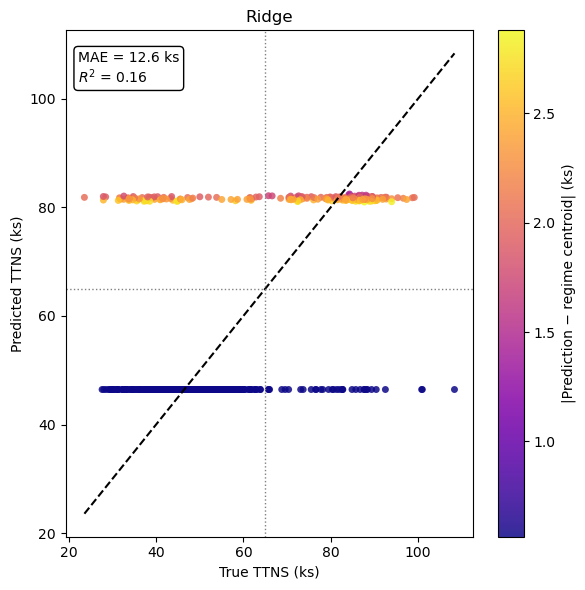

In [13]:
# ── Cell: Predicted vs True TTNS (Ridge QRC), single panel ────────────────────
import matplotlib.pyplot as plt

test_pred = ensemble_pred          # already computed by run_qrc_pipeline (Cell 12)
mae = mean_absolute_error(y_test_np, test_pred)
r2  = r2_score(y_test_np, test_pred)

# Regime centroid assigned to each test sample (classifier-predicted routing)
assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
color_vals = np.abs(test_pred - assigned_center) / 1000.0  # ks

fig, ax = plt.subplots(figsize=(6, 6))

sc = ax.scatter(
    y_test_np / 1000.0, test_pred / 1000.0,
    c=color_vals, cmap="plasma", s=25, alpha=0.85, edgecolors="none",
)

lims = [
    min(y_test_np.min(), test_pred.min()) / 1000.0,
    max(y_test_np.max(), test_pred.max()) / 1000.0,
]
ax.plot(lims, lims, "k--", linewidth=1.5)
ax.axhline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)
ax.axvline(boundary / 1000.0, color="gray", linestyle=":", linewidth=1)

ax.set_xlabel("True TTNS (ks)")
ax.set_ylabel("Predicted TTNS (ks)")
ax.set_title(f"{CLASSICAL_MODEL_NAME}")

ax.text(
    0.03, 0.96, f"MAE = {mae/1000:.1f} ks\n$R^2$ = {r2:.2f}",
    transform=ax.transAxes, va="top", fontsize=10,
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black"),
)

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("|Prediction − regime centroid| (ks)")

plt.tight_layout()
plt.show()

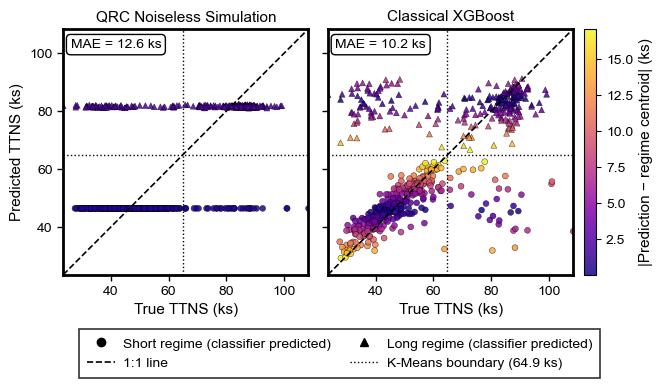

In [14]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

fig, axes = plt.subplots(1, 2, figsize=(6.89, 3.55), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("True TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    # MAE-only annotation, tucked in the corner so it doesn't sit over data
    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[0].set_ylabel("Predicted TTNS (ks)")

# ------------------------------------------------------------- boxed legend
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Short regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
           label="1:1 line"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Long regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.0,
           label=f"K-Means boundary ({boundary/1000:.1f} ks)"),
]

fig.legend(
    handles=legend_handles, ncol=2, loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    frameon=True, edgecolor="black", fancybox=False,
    handletextpad=0.6, columnspacing=1.4, borderpad=0.6,
)
fig.legends[0].get_frame().set_linewidth(1.2)

fig.tight_layout(rect=[0, 0.05, 0.90, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

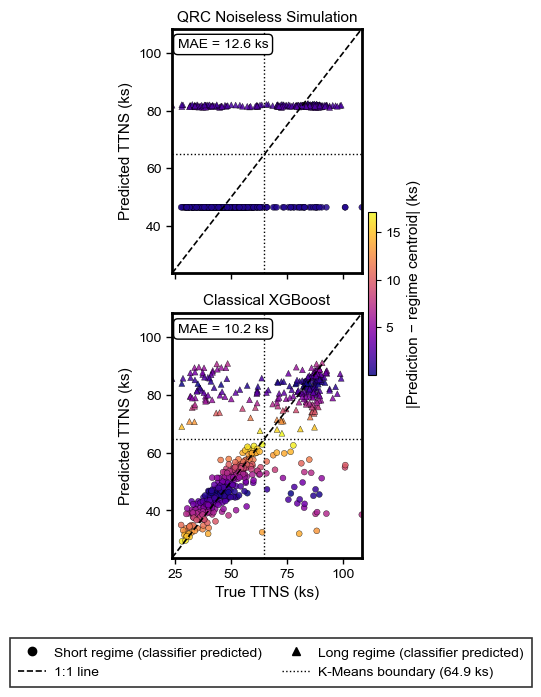

In [18]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

# Stacked vertically: single-column width, taller height for two rows
fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

# ------------------------------------------------------------- boxed legend
legend_handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Short regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=1.2,
           label="1:1 line"),
    Line2D([0], [0], marker="^", color="none", markerfacecolor="black",
           markeredgecolor="black", markersize=6,
           label="Long regime (classifier predicted)"),
    Line2D([0], [0], color="black", linestyle=":", linewidth=1.0,
           label=f"K-Means boundary ({boundary/1000:.1f} ks)"),
]

fig.legend(
    handles=legend_handles, ncol=2, loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    frameon=True, edgecolor="black", fancybox=False,
    handletextpad=0.6, columnspacing=1.4, borderpad=0.6,
)
fig.legends[0].get_frame().set_linewidth(1.2)

fig.tight_layout(rect=[0, 0.06, 0.86, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.03)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

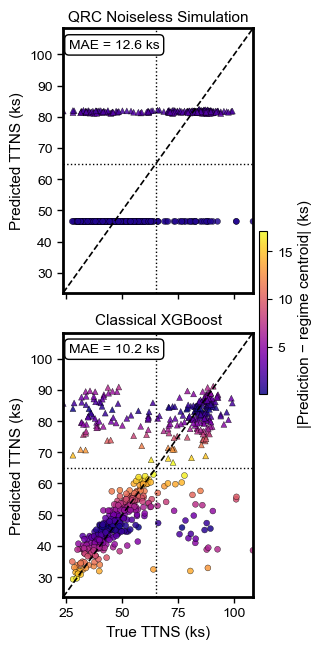

In [16]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

# Stacked vertically: single-column width, taller height for two rows
fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[0], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[1], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

fig.tight_layout(rect=[0, 0, 0.86, 1])
cbar = fig.colorbar(sc, ax=axes, fraction=0.04, pad=0.03)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("qrc_vs_xgb_ttns.png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

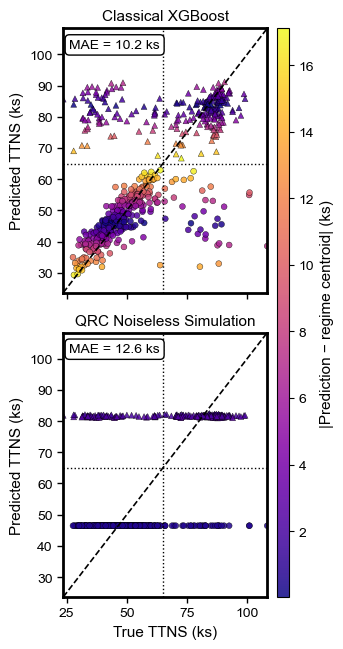

In [19]:
# ── Cell: Predicted vs True TTNS — QRC+Ridge vs. classical XGBoost ───────────
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------------------------------------------------------- global style
mpl.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "font.style": "normal",
    "mathtext.default": "regular",
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 11,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# Panel 1: QRC + Ridge
qrc_pred = ensemble_pred
qrc_mae  = mean_absolute_error(y_test_np, qrc_pred)

# Panel 2: classical XGBoost baseline
xgb_pred = final_predictions
xgb_mae  = mean_absolute_error(y_test_np, xgb_pred)

assigned_center = np.where(clf_test_labels == 0, centers[0], centers[1])
qrc_color_vals = np.abs(qrc_pred - assigned_center) / 1000.0  # ks
xgb_color_vals = np.abs(xgb_pred - assigned_center) / 1000.0  # ks

vmin = min(qrc_color_vals.min(), xgb_color_vals.min())
vmax = max(qrc_color_vals.max(), xgb_color_vals.max())

lims = [
    min(y_test_np.min(), qrc_pred.min(), xgb_pred.min()) / 1000.0,
    max(y_test_np.max(), qrc_pred.max(), xgb_pred.max()) / 1000.0,
]

regime_marker = {0: "o", 1: "^"}

fig, axes = plt.subplots(2, 1, figsize=(3.34, 6.6), sharex=True, sharey=True)

panels = [
    (axes[1], "QRC Noiseless Simulation", qrc_pred, qrc_color_vals, qrc_mae),
    (axes[0], "Classical XGBoost",        xgb_pred, xgb_color_vals, xgb_mae),
]

sc = None
for ax, title, pred, color_vals, mae in panels:
    for regime in (0, 1):
        mask = clf_test_labels == regime
        sc = ax.scatter(
            y_test_np[mask] / 1000.0, pred[mask] / 1000.0,
            c=color_vals[mask], cmap="plasma",
            marker=regime_marker[regime],
            s=18, alpha=0.85,
            edgecolors="black", linewidths=0.3,
            vmin=vmin, vmax=vmax,
        )

    ax.plot(lims, lims, color="black", linestyle="--", linewidth=1.2, zorder=1)
    ax.axhline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)
    ax.axvline(boundary / 1000.0, color="black", linestyle=":", linewidth=1.0, zorder=1)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_ylabel("Predicted TTNS (ks)")
    ax.set_title(title, fontweight="normal", fontstyle="normal")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    ax.grid(False)
    ax.tick_params(direction="out", width=1, length=4)

    ax.text(
        0.03, 0.96, f"MAE = {mae/1000:.1f} ks",
        transform=ax.transAxes, va="top", fontsize=10,
        fontweight="normal", fontstyle="normal",
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="black", linewidth=1),
    )

axes[-1].set_xlabel("True TTNS (ks)")

fig.tight_layout(rect=[0, 0, 0.86, 1])

# ------------------------------------------------------ colorbar, aligned to
# the exact vertical extent of both panels (top of panel 1 -> bottom of panel 2)
fig.canvas.draw()  # finalize axes positions before reading them
pos_top = axes[0].get_position()
pos_bot = axes[-1].get_position()
cbar_ax = fig.add_axes([
    pos_top.x1 + 0.03,      # x0: just right of the panels
    pos_bot.y0,             # y0: bottom of the lower panel
    0.035,                  # width
    pos_top.y1 - pos_bot.y0 # height: spans top panel's top to bottom panel's bottom
])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("|Prediction \u2212 regime centroid| (ks)")
cbar.ax.tick_params(labelsize=10)

# ---------------------------------------------------------------- save/export
fig.savefig("poster_qrc_vs_xgb_ttns.svg", bbox_inches="tight", pad_inches=0.02)

plt.show()